# Example 2: fitting a two-planet system (K2-24)

`RadVel` and `exoplanet` both have excellent tutorials where they fit for the two planets b and c of the K2-24 system. We will do the same here to show how to fit RV data for a multi-planet system in Ravest. This notebook fits the system twice, with circular and then eccentric orbits, showing how best to fit eccentric orbits in Ravest and comparing the two models.

This example builds on [Example 1: fitting a single planet](https://ravest.readthedocs.io/en/latest/Examples/example_1_fitting.html), so we skip over the basics of setting up a `Fitter` covered there.

**Links:**
- [Petigura et al. (2016) | ApJ 818 36](https://ui.adsabs.harvard.edu/abs/2016ApJ...818...36P/abstract): discovery paper on K2-24 b and c
- RadVel tutorial using K2-24: <https://radvel.readthedocs.io/en/latest/tutorials/K2-24_Fitting+MCMC.html>
- exoplanet tutorial using K2-24: <https://gallery.exoplanet.codes/tutorials/rv/>

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import ravest.prior
from ravest.fit import Fitter
from ravest.model import calculate_mpsini
from ravest.param import Parameter, Parameterisation

> **Important:** to keep this example quick to run and its outputs reproducible, it takes two shortcuts that you should **not** copy in your own fits:
>
> - **Few walkers and short chains.** The MCMC runs here use far fewer walkers, and far fewer steps, than a real fit would. Ravest requires at least $2\times$ the number of free parameters; for real fits a couple of hundred walkers is a sensible starting point, and you should run until the chains have converged (e.g. `check_convergence=True` in `run_mcmc`).
> - **A fixed random seed.** The next cell (collapsed on the website) fixes NumPy's random seed so that re-running this notebook gives identical results. **Remove it in your own fits: never freeze the random seed for real analysis.**

In [ ]:
# WARNING: this fixes NumPy's random seed ONLY so this tutorial's outputs are reproducible.
# Do NOT copy this into your own fits: remove it, and do not freeze the random seed.
np.random.seed(42)

## Load and inspect the RV data

In [ ]:
fpath = Path.cwd() / "example_data" / "K2-24.csv"
data = pd.read_csv(fpath)
data.head()

,errvel,time,vel,tel
0,1.593725,2364.819580,6.959066,HIRES
1,1.600745,2364.825101,5.017650,HIRES
2,1.658815,2364.830703,13.811799,HIRES
3,1.653224,2366.827579,1.151030,HIRES
4,1.639095,2367.852646,9.389273,HIRES


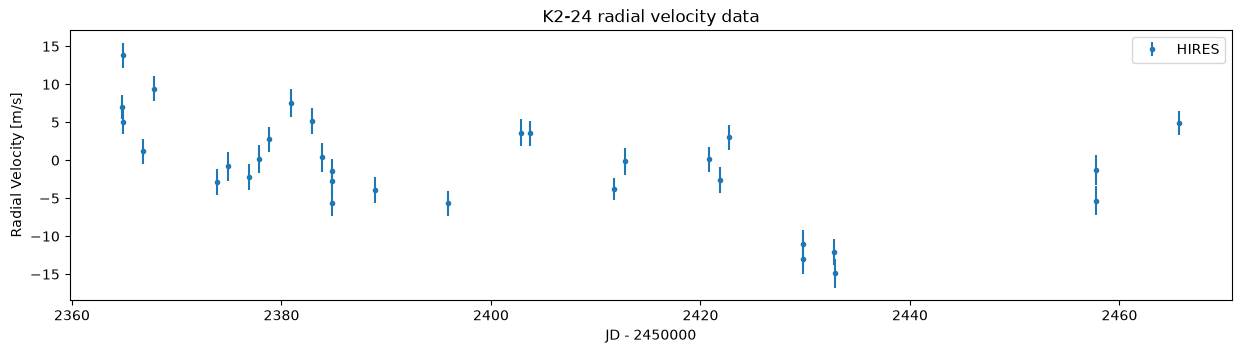

In [ ]:
plt.figure(figsize=(15,3.5))
plt.title("K2-24 radial velocity data")
plt.ylabel("Radial Velocity [m/s]")
plt.xlabel("JD - 2450000")
plt.errorbar(data["time"], data["vel"], yerr=data["errvel"], marker=".", label="HIRES", linestyle="None")
plt.legend()
plt.show()

## Circular orbits

### Set up the `Fitter`

We set up the `Fitter` as in Example 1. To fit circular orbits, we fix $e=0$ for both planets; the argument of periastron $\omega_\star$ is then undefined, so we fix it at an arbitrary value (by convention, $\pi/2$).

In [ ]:
fitter = Fitter(
                planet_letters=["b","c"], 
                parameterisation=Parameterisation("P K e w Tc")
                )

fitter.add_data(
                time=data["time"].to_numpy(), 
                vel=data["vel"].to_numpy(), 
                velerr=data["errvel"].to_numpy(),
                instrument=data["tel"].to_numpy(),
                t0=2420  # arbitrary reference time for trends, roughly in the middle of the data set
                )

# Construct the params dict
# These values will be used as the value for fixed parameters and the initial guess for the MAP fit for free parameters
params = {
          # Planet b parameters
          "P_b": Parameter(20.8853, "d", fixed=True),
          "K_b": Parameter(10, "m/s", fixed=False),
          "e_b": Parameter(0, "", fixed=True),
          "w_b": Parameter(np.pi/2, "rad", fixed=True),
          "Tc_b": Parameter(2072.7944, "d", fixed=True),

          # Planet c parameters
          "P_c": Parameter(42.3630, "d", fixed=True),
          "K_c": Parameter(10, "m/s", fixed=False),
          "e_c": Parameter(0, "", fixed=True),
          "w_c": Parameter(np.pi/2, "rad", fixed=True),
          "Tc_c": Parameter(2082.6252, "d", fixed=True),
          
          # Instrumental parameters
          "g_HIRES": Parameter(0, "m/s", fixed=False),
          "jit_HIRES": Parameter(0, "m/s", fixed=False),

          # System trend parameters
          "gd": Parameter(0, "m/s/day", fixed=False),
          "gdd": Parameter(0, "m/s/day^2", fixed=False),
          }

# Add the params dict to the fitter
fitter.params = params
fitter.params

{'P_b': Parameter(value=20.8853, unit='d', fixed=True),
 'K_b': Parameter(value=10, unit='m/s', fixed=False),
 'e_b': Parameter(value=0, unit='', fixed=True),
 'w_b': Parameter(value=1.5707963267948966, unit='rad', fixed=True),
 'Tc_b': Parameter(value=2072.7944, unit='d', fixed=True),
 'P_c': Parameter(value=42.363, unit='d', fixed=True),
 'K_c': Parameter(value=10, unit='m/s', fixed=False),
 'e_c': Parameter(value=0, unit='', fixed=True),
 'w_c': Parameter(value=1.5707963267948966, unit='rad', fixed=True),
 'Tc_c': Parameter(value=2082.6252, unit='d', fixed=True),
 'g_HIRES': Parameter(value=0, unit='m/s', fixed=False),
 'jit_HIRES': Parameter(value=0, unit='m/s', fixed=False),
 'gd': Parameter(value=0, unit='m/s/day', fixed=False),
 'gdd': Parameter(value=0, unit='m/s/day^2', fixed=False)}

### Priors

Define the prior functions for the free parameters. You can see a list of available prior functions at `ravest.prior.PRIOR_FUNCTIONS`.

In [ ]:
ravest.prior.PRIOR_FUNCTIONS

['Uniform',
 'EccentricityUniform',
 'Normal',
 'TruncatedNormal',
 'HalfNormal',
 'Rayleigh',
 'VanEylen19Mixture',
 'Beta']

In [ ]:
# Construct the priors dict. Every parameter that isn't fixed requires a prior.
priors = {
          "K_b": ravest.prior.Uniform(lower=0, upper=50),
          "K_c": ravest.prior.Uniform(lower=0, upper=50),

          "g_HIRES": ravest.prior.Uniform(lower=-10, upper=10),
          "jit_HIRES": ravest.prior.Uniform(lower=0, upper=5),

          "gd": ravest.prior.Uniform(lower=-0.1, upper=0.1),
          "gdd": ravest.prior.Uniform(lower=-0.01, upper=0.01),
         }

# Add the priors dict to the fitter
fitter.priors = priors
fitter.priors

{'K_b': Uniform(lower=0, upper=50),
 'K_c': Uniform(lower=0, upper=50),
 'g_HIRES': Uniform(lower=-10, upper=10),
 'jit_HIRES': Uniform(lower=0, upper=5),
 'gd': Uniform(lower=-0.1, upper=0.1),
 'gdd': Uniform(lower=-0.01, upper=0.01)}

### The initial MAP fit

As in Example 1, we first find the Maximum A Posteriori (MAP) solution, as a starting point for the MCMC.

In [ ]:
map_results = fitter.find_map_estimate(method="Powell")
map_results

MAP parameter results: {'K_b': np.float64(4.728018067635626), 'K_c': np.float64(3.9484526206428083), 'g_HIRES': np.float64(-4.02105691919244), 'jit_HIRES': np.float64(2.7192413642372064), 'gd': np.float64(-0.030770893852872162), 'gdd': np.float64(0.0018080187133742915)}


 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 89.67950393517822
       x: [ 4.728e+00  3.948e+00 -4.021e+00  2.719e+00 -3.077e-02
            1.808e-03]
     nit: 7
   direc: [[ 1.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
           [ 2.245e-01  1.520e-01 ...  1.367e-02  5.979e-04]
           ...
           [-4.297e-01 -2.882e-01 ... -1.137e-02  1.817e-04]
           [-2.043e-02 -8.376e-02 ...  1.311e-03  4.932e-05]]
    nfev: 433

Let's take a look at what the RV looks like with these parameter values:

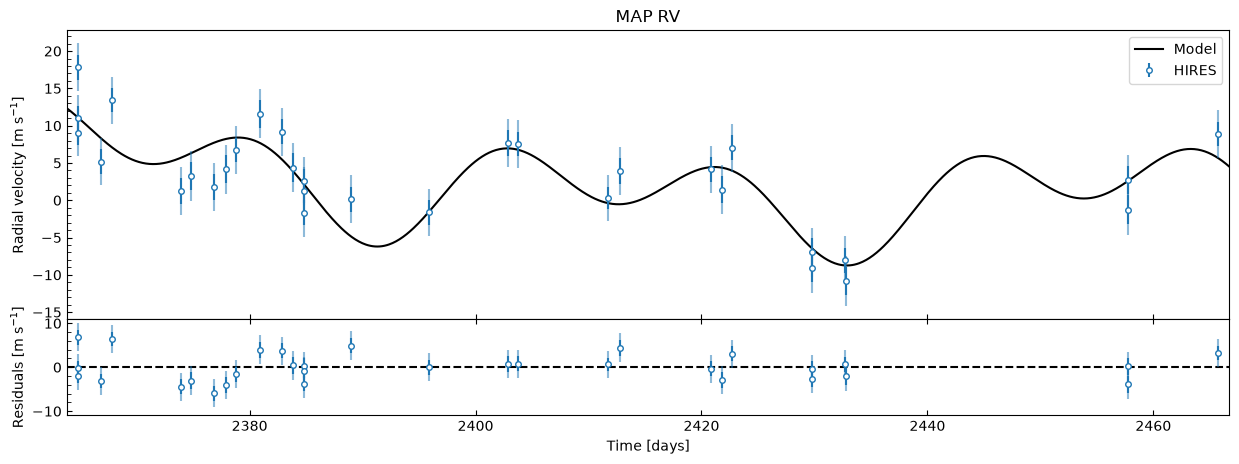

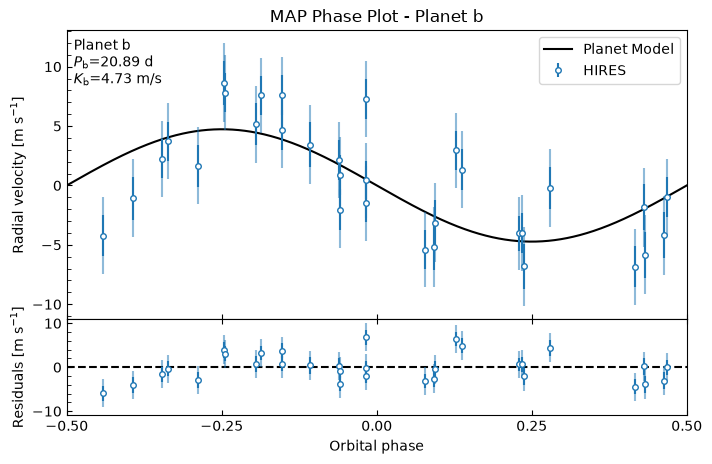

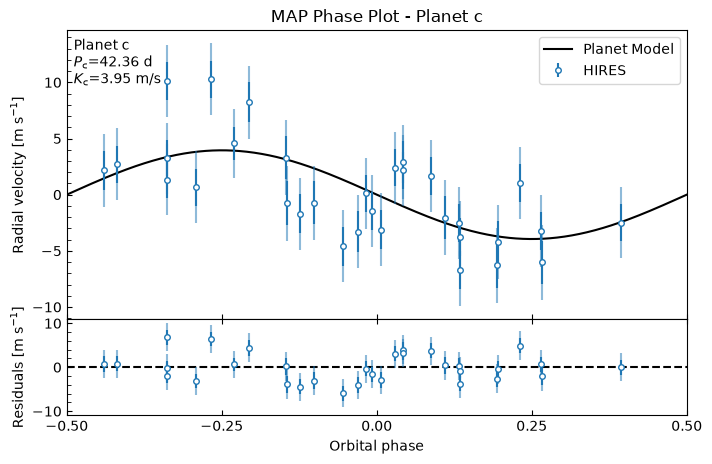

In [ ]:
fitter.plot_MAP_rv(map_result=map_results)
fitter.plot_MAP_phase(planet_letter="b", map_result=map_results)
fitter.plot_MAP_phase(planet_letter="c", map_result=map_results)

### The main MCMC fit

We can use MCMC to more fully explore the parameter space and estimate the parameter uncertainties. To keep this notebook quick, this only runs for 10,000 steps - you should run considerably more. You should also consider using randomly initialised starting points, rather than the MAP solution, to better explore the parameter space. Parallelisation has been (experimentally) enabled via the `multiprocessing` argument, which can result in significant speed-ups - especially for longer chains/more walkers.

In [ ]:
nwalkers = 20
mcmc_init = fitter.generate_initial_walker_positions_from_map(map_result=map_results, nwalkers=nwalkers, verbose=False)

In [ ]:
nsteps = 10_000  # You should definitely run for more steps than this!

# Fit the free parameters to the data. Use the MAP solution as the initial value for the MCMC walkers.
fitter.run_mcmc(initial_positions=mcmc_init, nwalkers=nwalkers, max_steps=nsteps, progress=True, multiprocessing=True)  # This will take a few minutes!

INFO:root:Starting MCMC for 10000 steps...
100%|██████████| 10000/10000 [00:10<00:00, 948.70it/s]
INFO:root:...MCMC done.


### Getting the MCMC samples

Now that the MCMC is finished, the state of the `emcee` sampler has been saved into the `Fitter` object. We can therefore export the posterior samples, as a `numpy` array that can be passed into other functions (such as for comparing two models by estimating the log Bayesian evidence $\ln\mathcal{Z}$ - see [Example 4: using the Learned Harmonic Mean Estimator](https://ravest.readthedocs.io/en/latest/Examples/example_4_harmonic.html)). We can also export them into a Pandas dataframe, which keeps each parameter labelled. In both cases, we can pass in the `discard_start` and `discard_end` arguments, to drop the burn-in or "zoom" in on certain areas of the chain by discarding other parts. The `thin` argument keeps only every `thin`-th sample, and the `flat` argument combines all of the different walkers for each parameter into one long chain per parameter.

In [ ]:
nburn = 1_000
thin_rate = 10

# Get the samples as a numpy array
samples = fitter.get_samples_np(discard_start=nburn, discard_end=0, thin=thin_rate, flat=False) # shape (nsteps, nwalkers, ndim)

# Get the samples as a labelled Pandas dataframe
samples_df = fitter.get_samples_df(discard_start=nburn, discard_end=0, thin=thin_rate)  # shape (nsteps*nwalkers, ndim)
samples_df

,K_b,K_c,g_HIRES,jit_HIRES,gd,gdd
0,5.268061,3.574319,-4.545910,2.736021,-0.006225,0.002566
1,4.687584,4.655487,-4.171766,2.414982,-0.037531,0.001620
2,3.555249,4.401739,-3.740352,2.907973,-0.078077,0.001721
3,4.096877,3.046425,-3.696339,3.666548,0.000406,0.002666
4,3.918901,3.542980,-4.792268,2.776779,-0.022508,0.003011
...,...,...,...,...,...,...
17995,5.686545,3.984359,-3.291586,2.104096,0.027521,0.002390
17996,6.035929,5.994605,-2.382062,2.957106,-0.043938,0.000423
17997,4.508401,2.946867,-3.327875,3.778832,0.007286,0.002241
17998,4.292817,2.833888,-4.842609,4.058965,0.017387,0.003245


### MCMC diagnostics

To inspect the chains visually, we can plot (and optionally save) the time series of each parameter in the chain. We see that after a brief period around the initial values (which we expect, as we started the walkers at the MAP values, so they'll be starting at an area of maximised likelihood), they eventually break out and start exploring the parameter space more. For all future plots we can discard this initial "burn-in" with the `discard_start` argument.

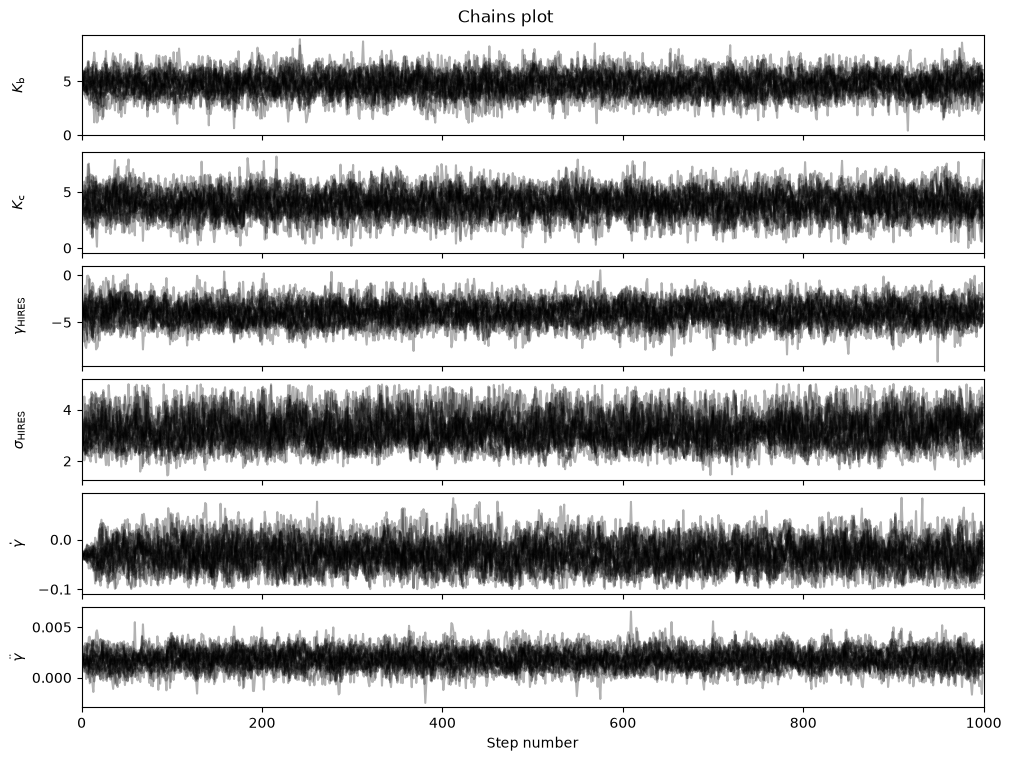

In [ ]:
fitter.plot_chains(discard_start=0, discard_end=0, thin=thin_rate, save=False)

### Results

We can visualise the posterior parameter distributions in corner plots, using the `corner` module.

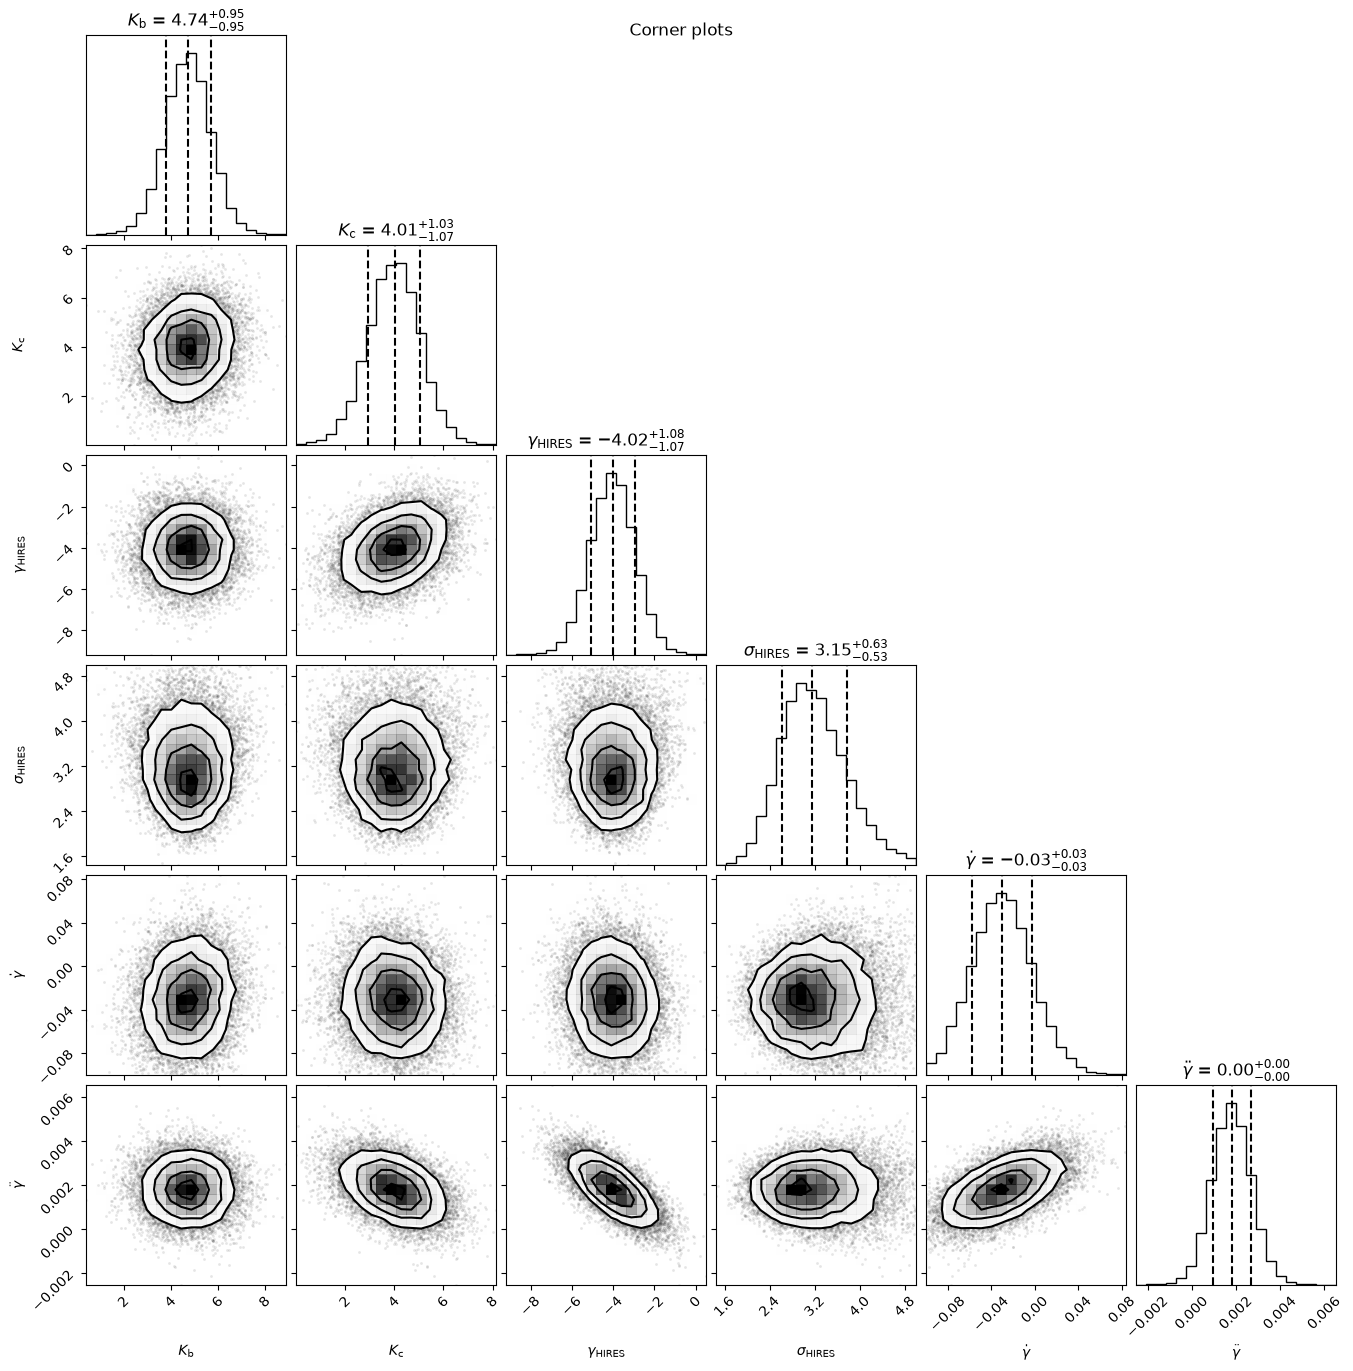

In [ ]:
fitter.plot_corner(discard_start=nburn, discard_end=0, thin=thin_rate, plot_datapoints=True, save=False)

Inspecting the posteriors, we can see the 16th, 50th and 84th percentiles are shown, which could be used for a quoted value and uncertainty. It's a good idea to inspect the posterior distribution visually with the corner plots though, as they may not always be nice Gaussians, which means those percentiles may not be a good representation. (This is often the case for eccentricity!). For further analysis and inspection, recall that we can get a dataframe of the samples (e.g. to plot them in a histogram to inspect the distribution closer) by using the `Fitter.get_samples_df()` method that we saw earlier.

#### Posterior RV and phase plots

Let's see what the posterior RV looks like - we'll calculate the RV for each of the MCMC samples, then we plot the median RV and 16-84 percentiles at each timestep. We'll also look at each planet's contribution in isolation with phase plots.

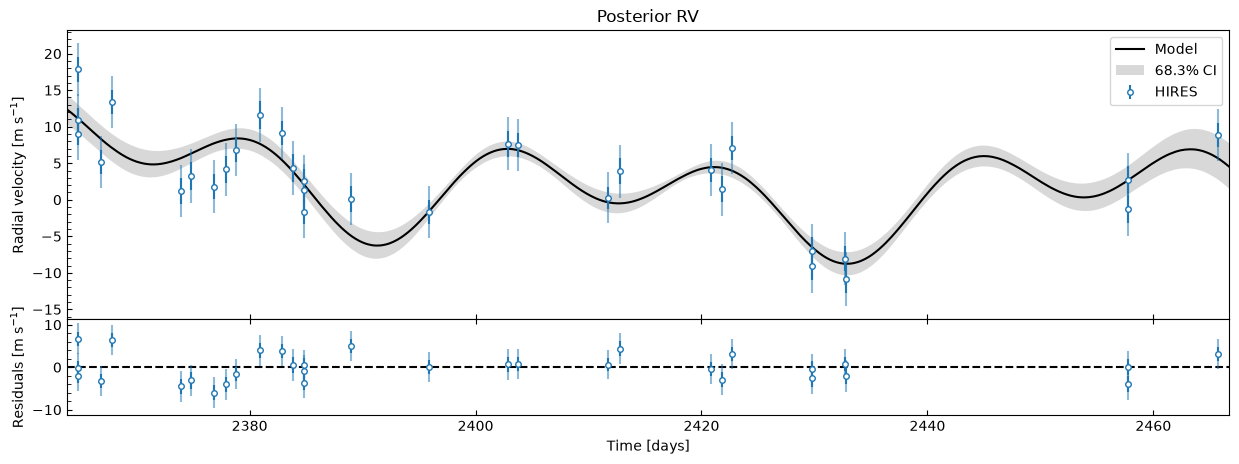

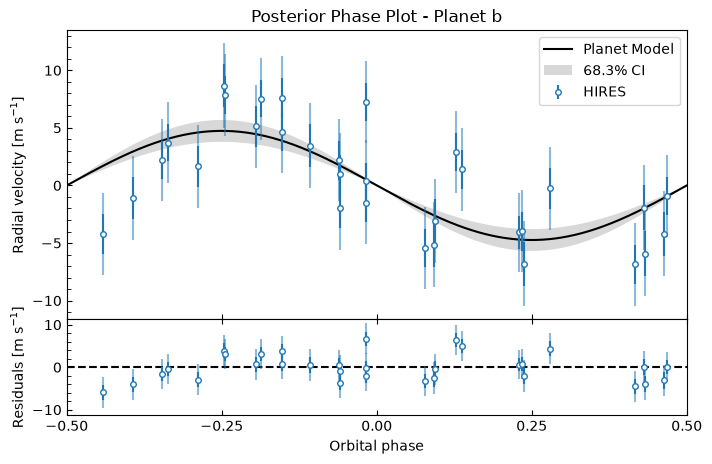

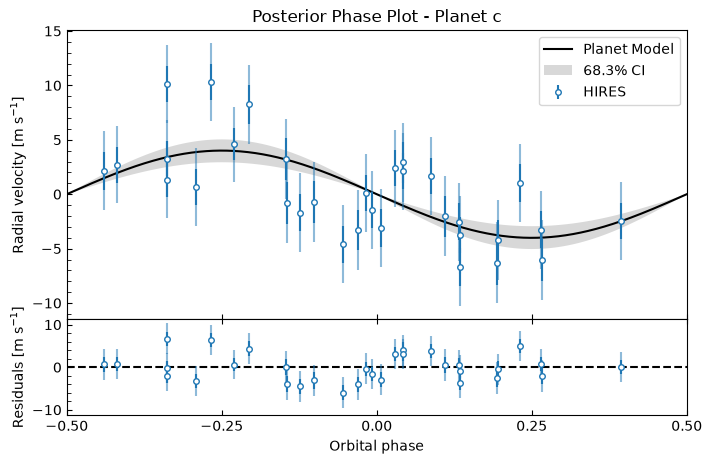

In [ ]:
fitter.plot_posterior_rv(discard_start=nburn, discard_end=0, thin=thin_rate)
fitter.plot_posterior_phase("b", discard_start=nburn, discard_end=0, thin=thin_rate)
fitter.plot_posterior_phase("c", discard_start=nburn, discard_end=0, thin=thin_rate)

### Minimum masses $M_p\sin{i}$

To calculate planetary mass estimates $M_p\sin{i}$, we need to know the stellar mass. Using the value $M_\star=1.12\pm0.05$ used in Petigura et al. 2016, we can generate a distribution of stellar mass values from the published value and uncertainty, and draw from that distribution to use as the value of $M_\star$ in the conversion equation.

In [ ]:
# Stellar mass values from Petigura et al. 2016
mstar_val = 1.12  # [M_sun]
mstar_err = 0.05 # [M_sun]

# Create a distribution of stellar mass values from the published value and uncertainty
mstar = np.random.normal(loc=mstar_val, scale=mstar_err, size=len(samples_df))
# Ensure all values in mstar are positive (incredibly unlikely to be an issue with these values, but just in case)
while any(mstar <= 0):
    mstar[mstar <= 0] = np.random.normal(loc=mstar_val, scale=mstar_err, size=sum(mstar <= 0))

K2-24 b Mpsini: 21.98 +4.43 -4.42 M_earth
K2-24 c Mpsini: 23.53 +6.10 -6.26 M_earth


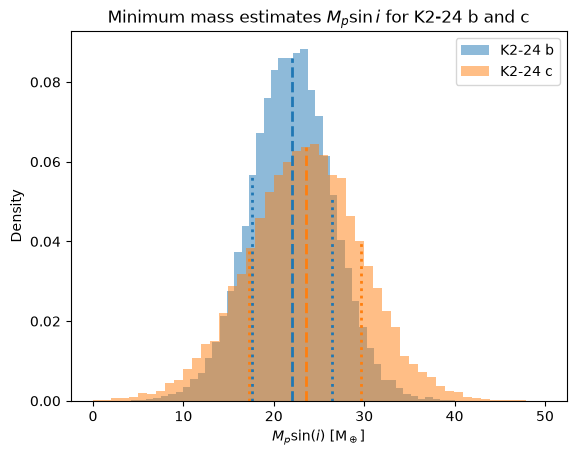

In [ ]:
# get the posterior samples (both free and fixed) as a dictionary
posterior_params = fitter.get_mcmc_posterior_dict(discard_start=nburn, discard_end=0, thin=thin_rate)

# use the MCMC samples and the stellar mass distribution to get a distribution for Mp sin(i)
mpsini_b = calculate_mpsini(mstar, posterior_params["P_b"], posterior_params["K_b"], posterior_params["e_b"], unit="M_earth")
mpsini_c = calculate_mpsini(mstar, posterior_params["P_c"], posterior_params["K_c"], posterior_params["e_c"], unit="M_earth")

# Plot the mpsini posterior distributions overlapping
fig, ax = plt.subplots(1, 1)
ax.set_title("Minimum mass estimates $M_p\\sin{i}$ for K2-24 b and c")
ax.set_xlabel("$M_p \\sin(i)$ [M$_\\oplus$]")
ax.set_ylabel("Density")

# Plot both histograms first, normalised so they're visually comparable
plot_b = ax.hist(mpsini_b, bins=50, color="tab:blue", alpha=0.5, label="K2-24 b", density=True)
plot_c = ax.hist(mpsini_c, bins=50, color="tab:orange", alpha=0.5, label="K2-24 c", density=True)

# Get the final y-axis bound after both histograms are drawn
_, ymax = ax.get_ybound()

# Overplot percentile lines for planet b
ps_b = np.percentile(mpsini_b, [16, 50, 84])
heights_b = plot_b[0][np.searchsorted(plot_b[1], ps_b, side='left') - 1]
ax.axvline(ps_b[0], color='tab:blue', linestyle=':', linewidth=2, ymax=heights_b[0] / ymax)
ax.axvline(ps_b[1], color='tab:blue', linestyle='--', linewidth=2, ymax=heights_b[1] / ymax)
ax.axvline(ps_b[2], color='tab:blue', linestyle=':', linewidth=2, ymax=heights_b[2] / ymax)

# Overplot percentile lines for planet c
ps_c = np.percentile(mpsini_c, [16, 50, 84])
heights_c = plot_c[0][np.searchsorted(plot_c[1], ps_c, side='left') - 1]
ax.axvline(ps_c[0], color='tab:orange', linestyle=':', linewidth=2, ymax=heights_c[0] / ymax)
ax.axvline(ps_c[1], color='tab:orange', linestyle='--', linewidth=2, ymax=heights_c[1] / ymax)
ax.axvline(ps_c[2], color='tab:orange', linestyle=':', linewidth=2, ymax=heights_c[2] / ymax)

ax.legend(loc="upper right")

print(f"K2-24 b Mpsini: {ps_b[1]:.2f} +{ps_b[2]-ps_b[1]:.2f} -{ps_b[1]-ps_b[0]:.2f} M_earth")
print(f"K2-24 c Mpsini: {ps_c[1]:.2f} +{ps_c[2]-ps_c[1]:.2f} -{ps_c[1]-ps_c[0]:.2f} M_earth")

---

## Eccentric orbits

### Set up the `Fitter`

Let's make a new `Fitter` object and fit for eccentricity. We'll fit in the $\sqrt{e}\cos{\omega_\star}$ and $\sqrt{e}\sin{\omega_\star}$ by using the `"secosw sesinw"` parameterisation.

In [ ]:
# Fit in the sqrt(e) "se" parameterisation
parameterisation_se = Parameterisation("P K secosw sesinw Tc")

fitter_se = Fitter(
                   planet_letters=["b","c"], 
                   parameterisation=parameterisation_se
                   )

fitter_se.add_data(
                   time=data["time"].to_numpy(), 
                   vel=data["vel"].to_numpy(), 
                   velerr=data["errvel"].to_numpy(), 
                   instrument=data["tel"].to_numpy(),
                   t0=2420  # arbitrary reference time for trends, roughly in the middle of the data set
                   )

print(fitter_se.t0)

# Construct the params dict
# These values will be used as the value for fixed parameters and the initial guess for the MAP fit for free parameters
params_se = {
             # Planet b parameters
             "P_b": Parameter(20.8853, "d", fixed=True),
             "K_b": Parameter(np.exp(1.55037), "m/s", fixed=False),
             "secosw_b": Parameter(0.01, "", fixed=False),
             "sesinw_b": Parameter(0.01, "", fixed=False),
             "Tc_b": Parameter(2072.7944, "d", fixed=True),
             
             # Planet c parameters
             "P_c": Parameter(42.3630, "d", fixed=True),
             "K_c": Parameter(np.exp(1.37648), "m/s", fixed=False),
             "secosw_c": Parameter(0.01, "", fixed=False),
             "sesinw_c": Parameter(0.01, "", fixed=False),
             "Tc_c": Parameter(2082.6252, "d", fixed=True),
             
             # Instrumental parameters
             "g_HIRES": Parameter(-3.99195, "m/s", fixed=False),
             "jit_HIRES": Parameter(2.09753, "m/s", fixed=False),

             # System trend parameters
             "gd": Parameter(0, "m/s/day", fixed=False),
             "gdd": Parameter(0, "m/s/day^2", fixed=False),
             }

# Add the params dict to the fitter
fitter_se.params = params_se
fitter_se.params

2420


{'P_b': Parameter(value=20.8853, unit='d', fixed=True),
 'K_b': Parameter(value=np.float64(4.7132137490982124), unit='m/s', fixed=False),
 'secosw_b': Parameter(value=0.01, unit='', fixed=False),
 'sesinw_b': Parameter(value=0.01, unit='', fixed=False),
 'Tc_b': Parameter(value=2072.7944, unit='d', fixed=True),
 'P_c': Parameter(value=42.363, unit='d', fixed=True),
 'K_c': Parameter(value=np.float64(3.9609345702082397), unit='m/s', fixed=False),
 'secosw_c': Parameter(value=0.01, unit='', fixed=False),
 'sesinw_c': Parameter(value=0.01, unit='', fixed=False),
 'Tc_c': Parameter(value=2082.6252, unit='d', fixed=True),
 'g_HIRES': Parameter(value=-3.99195, unit='m/s', fixed=False),
 'jit_HIRES': Parameter(value=2.09753, unit='m/s', fixed=False),
 'gd': Parameter(value=0, unit='m/s/day', fixed=False),
 'gdd': Parameter(value=0, unit='m/s/day^2', fixed=False)}

### Priors

We could put `Uniform` priors on $\sqrt{e}\cos{\omega_\star}$ and $\sqrt{e}\sin{\omega_\star}$ directly, but instead we'll put them on the equivalent parameters $e$ and $\omega_\star$, as you can for any parameter in its default-parameterisation form in Ravest (so you could fit in $T_\text{C}$ but put a prior on $T_\text{P}$.. not sure why you would want to though!) 

For eccentricity, we recommend `EccentricityUniform` over `Uniform`: it uses the half-open interval $[0, \text{upper})$, which allows circular orbits ($e=0$) while excluding the upper bound. Ravest automatically applies the constant log-posterior correction this choice requires if you later use `harmonic` to compute log evidences for model comparisons - see [Log-posterior corrections](https://ravest.readthedocs.io/en/latest/logprob_corrections.html).

In [ ]:
# Construct the priors dict. Every parameter that isn't fixed requires a prior.
priors_se = {
             "K_b": ravest.prior.Uniform(lower=0, upper=50),
             "e_b": ravest.prior.EccentricityUniform(upper=0.8),     # Prior on e & w, even though fitting in secosw sesinw
             "w_b": ravest.prior.Uniform(lower=-np.pi, upper=np.pi),

             "K_c": ravest.prior.Uniform(lower=0, upper=50),
             "e_c": ravest.prior.EccentricityUniform(upper=0.8),     # Prior on e & w, even though fitting in secosw sesinw
             "w_c": ravest.prior.Uniform(lower=-np.pi, upper=np.pi),

             "g_HIRES": ravest.prior.Uniform(lower=-10, upper=10),
             "jit_HIRES": ravest.prior.Uniform(lower=0, upper=5),

             "gd": ravest.prior.Uniform(lower=-0.1, upper=0.1),
             "gdd": ravest.prior.Uniform(lower=-0.01, upper=0.01),
             }

# Add the priors dict to the fitter
fitter_se.priors = priors_se
fitter_se.priors

{'K_b': Uniform(lower=0, upper=50),
 'e_b': EccentricityUniform(upper=0.8),
 'w_b': Uniform(lower=-3.141592653589793, upper=3.141592653589793),
 'K_c': Uniform(lower=0, upper=50),
 'e_c': EccentricityUniform(upper=0.8),
 'w_c': Uniform(lower=-3.141592653589793, upper=3.141592653589793),
 'g_HIRES': Uniform(lower=-10, upper=10),
 'jit_HIRES': Uniform(lower=0, upper=5),
 'gd': Uniform(lower=-0.1, upper=0.1),
 'gdd': Uniform(lower=-0.01, upper=0.01)}

### The initial MAP fit

In [ ]:
map_results_se = fitter_se.find_map_estimate(method="Powell")
map_results_se

MAP parameter results: {'K_b': np.float64(6.096747810573451), 'secosw_b': np.float64(0.3908072157918322), 'sesinw_b': np.float64(-0.4182704140393492), 'K_c': np.float64(4.368625748330783), 'secosw_c': np.float64(-0.13618562670282286), 'sesinw_c': np.float64(0.3607463372228259), 'g_HIRES': np.float64(-4.549963412184575), 'jit_HIRES': np.float64(1.9468791573153021), 'gd': np.float64(-0.029787499282231237), 'gdd': np.float64(0.0020854630745467616)}


 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 84.64844716728268
       x: [ 6.097e+00  3.908e-01 -4.183e-01  4.369e+00 -1.362e-01
            3.607e-01 -4.550e+00  1.947e+00 -2.979e-02  2.085e-03]
     nit: 11
   direc: [[ 1.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00 ...  0.000e+00  0.000e+00]
           ...
           [ 0.000e+00  0.000e+00 ...  1.000e+00  0.000e+00]
           [-7.799e-02 -2.027e-03 ...  1.847e-03  1.137e-04]]
    nfev: 1219

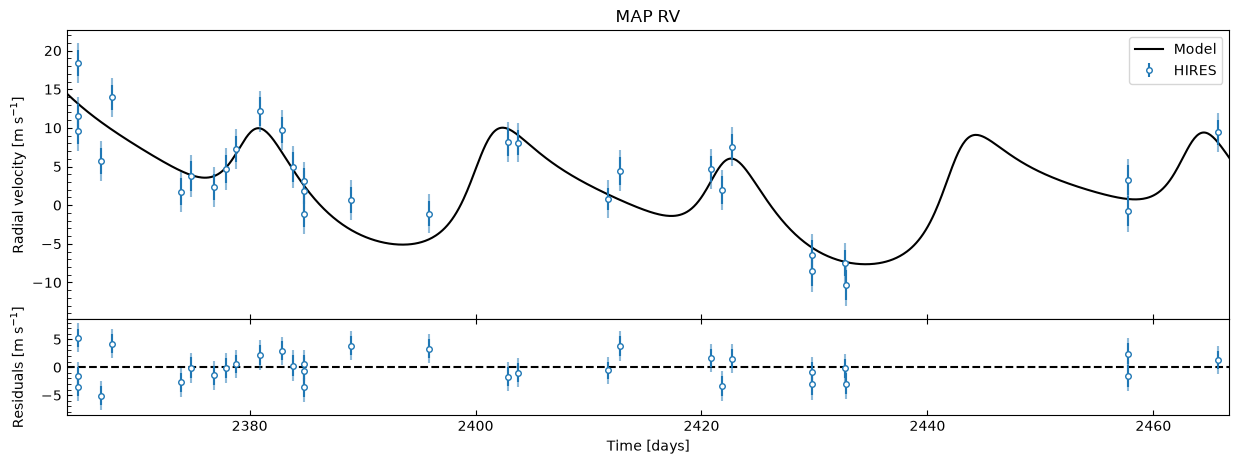

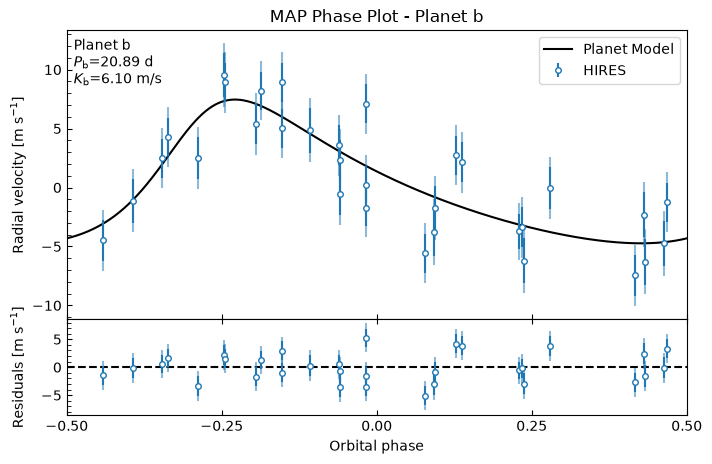

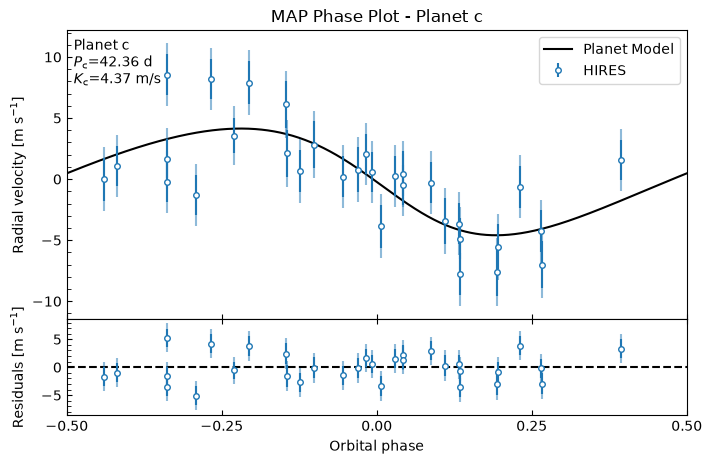

In [ ]:
fitter_se.plot_MAP_rv(map_result=map_results_se)
fitter_se.plot_MAP_phase(planet_letter="b", map_result=map_results_se)
fitter_se.plot_MAP_phase(planet_letter="c", map_result=map_results_se)

We can already see that the residuals are generally tighter than they were in the circular case.

### The main MCMC fit

In [ ]:
nwalkers_se = 20
mcmc_init_se = fitter_se.generate_initial_walker_positions_from_map(map_result=map_results_se, nwalkers=nwalkers_se, verbose=False)

In [ ]:
nsteps = 10_000

# Fit the free parameters to the data
samples_se = fitter_se.run_mcmc(initial_positions=mcmc_init_se, nwalkers=nwalkers_se, max_steps=nsteps, progress=True, multiprocessing=True)  # This will take a while!

INFO:root:Starting MCMC for 10000 steps...
100%|██████████| 10000/10000 [00:11<00:00, 849.74it/s]
INFO:root:...MCMC done.


### Getting the MCMC samples

In [ ]:
# Get the samples as a numpy array
samples_se = fitter_se.get_samples_np(discard_start=nburn, discard_end=0, thin=thin_rate, flat=False) # shape (nsteps, nwalkers, ndim)

# Get the samples as a labelled Pandas dataframe
samples_df_se = fitter_se.get_samples_df(discard_start=nburn, discard_end=0, thin=thin_rate)  # shape (nsteps*nwalkers, ndim)
samples_df_se

,K_b,secosw_b,sesinw_b,K_c,secosw_c,sesinw_c,g_HIRES,jit_HIRES,gd,gdd
0,4.467599,0.387744,0.016857,4.140598,-0.197327,-0.734652,-5.528274,2.333838,-0.034529,0.003283
1,5.341343,0.327371,-0.441100,2.458695,-0.298858,0.254742,-6.371720,2.951831,-0.016530,0.003502
2,3.105443,0.194489,-0.720922,4.279817,-0.120116,-0.399357,-5.493603,2.816443,-0.053090,0.002085
3,4.704746,0.197553,-0.772069,3.286763,-0.122130,0.051531,-3.571690,3.325485,-0.025534,0.002056
4,5.010418,0.423342,-0.072839,4.064817,-0.166531,-0.167807,-3.531316,3.243125,-0.042146,0.000655
...,...,...,...,...,...,...,...,...,...,...
17995,5.737519,0.316535,-0.563535,1.684233,-0.098412,0.339819,-5.277605,2.764505,-0.036974,0.002486
17996,4.742449,0.410229,-0.241498,4.326090,0.074540,0.010930,-2.826085,3.161373,-0.036905,0.000909
17997,5.774602,0.360150,-0.394117,4.608829,-0.362509,0.275290,-3.462290,2.143321,0.037193,0.002789
17998,7.163632,0.383039,-0.384567,4.450729,0.008950,0.028941,-4.678478,2.114286,-0.056870,0.001109


### MCMC diagnostics

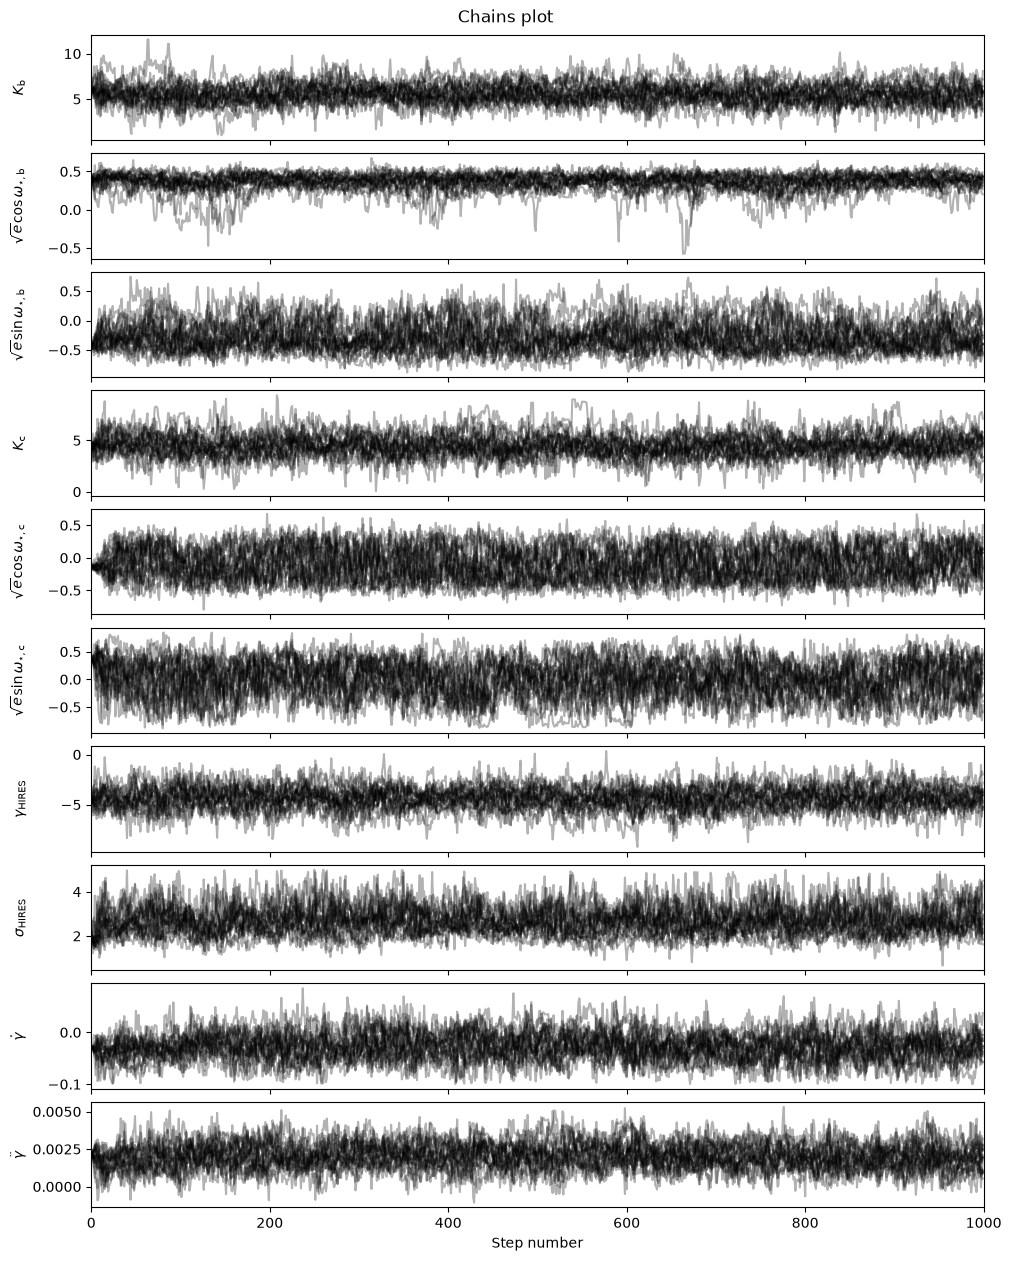

In [ ]:
fitter_se.plot_chains(discard_start=0, discard_end=0, thin=thin_rate, save=False)

### Results

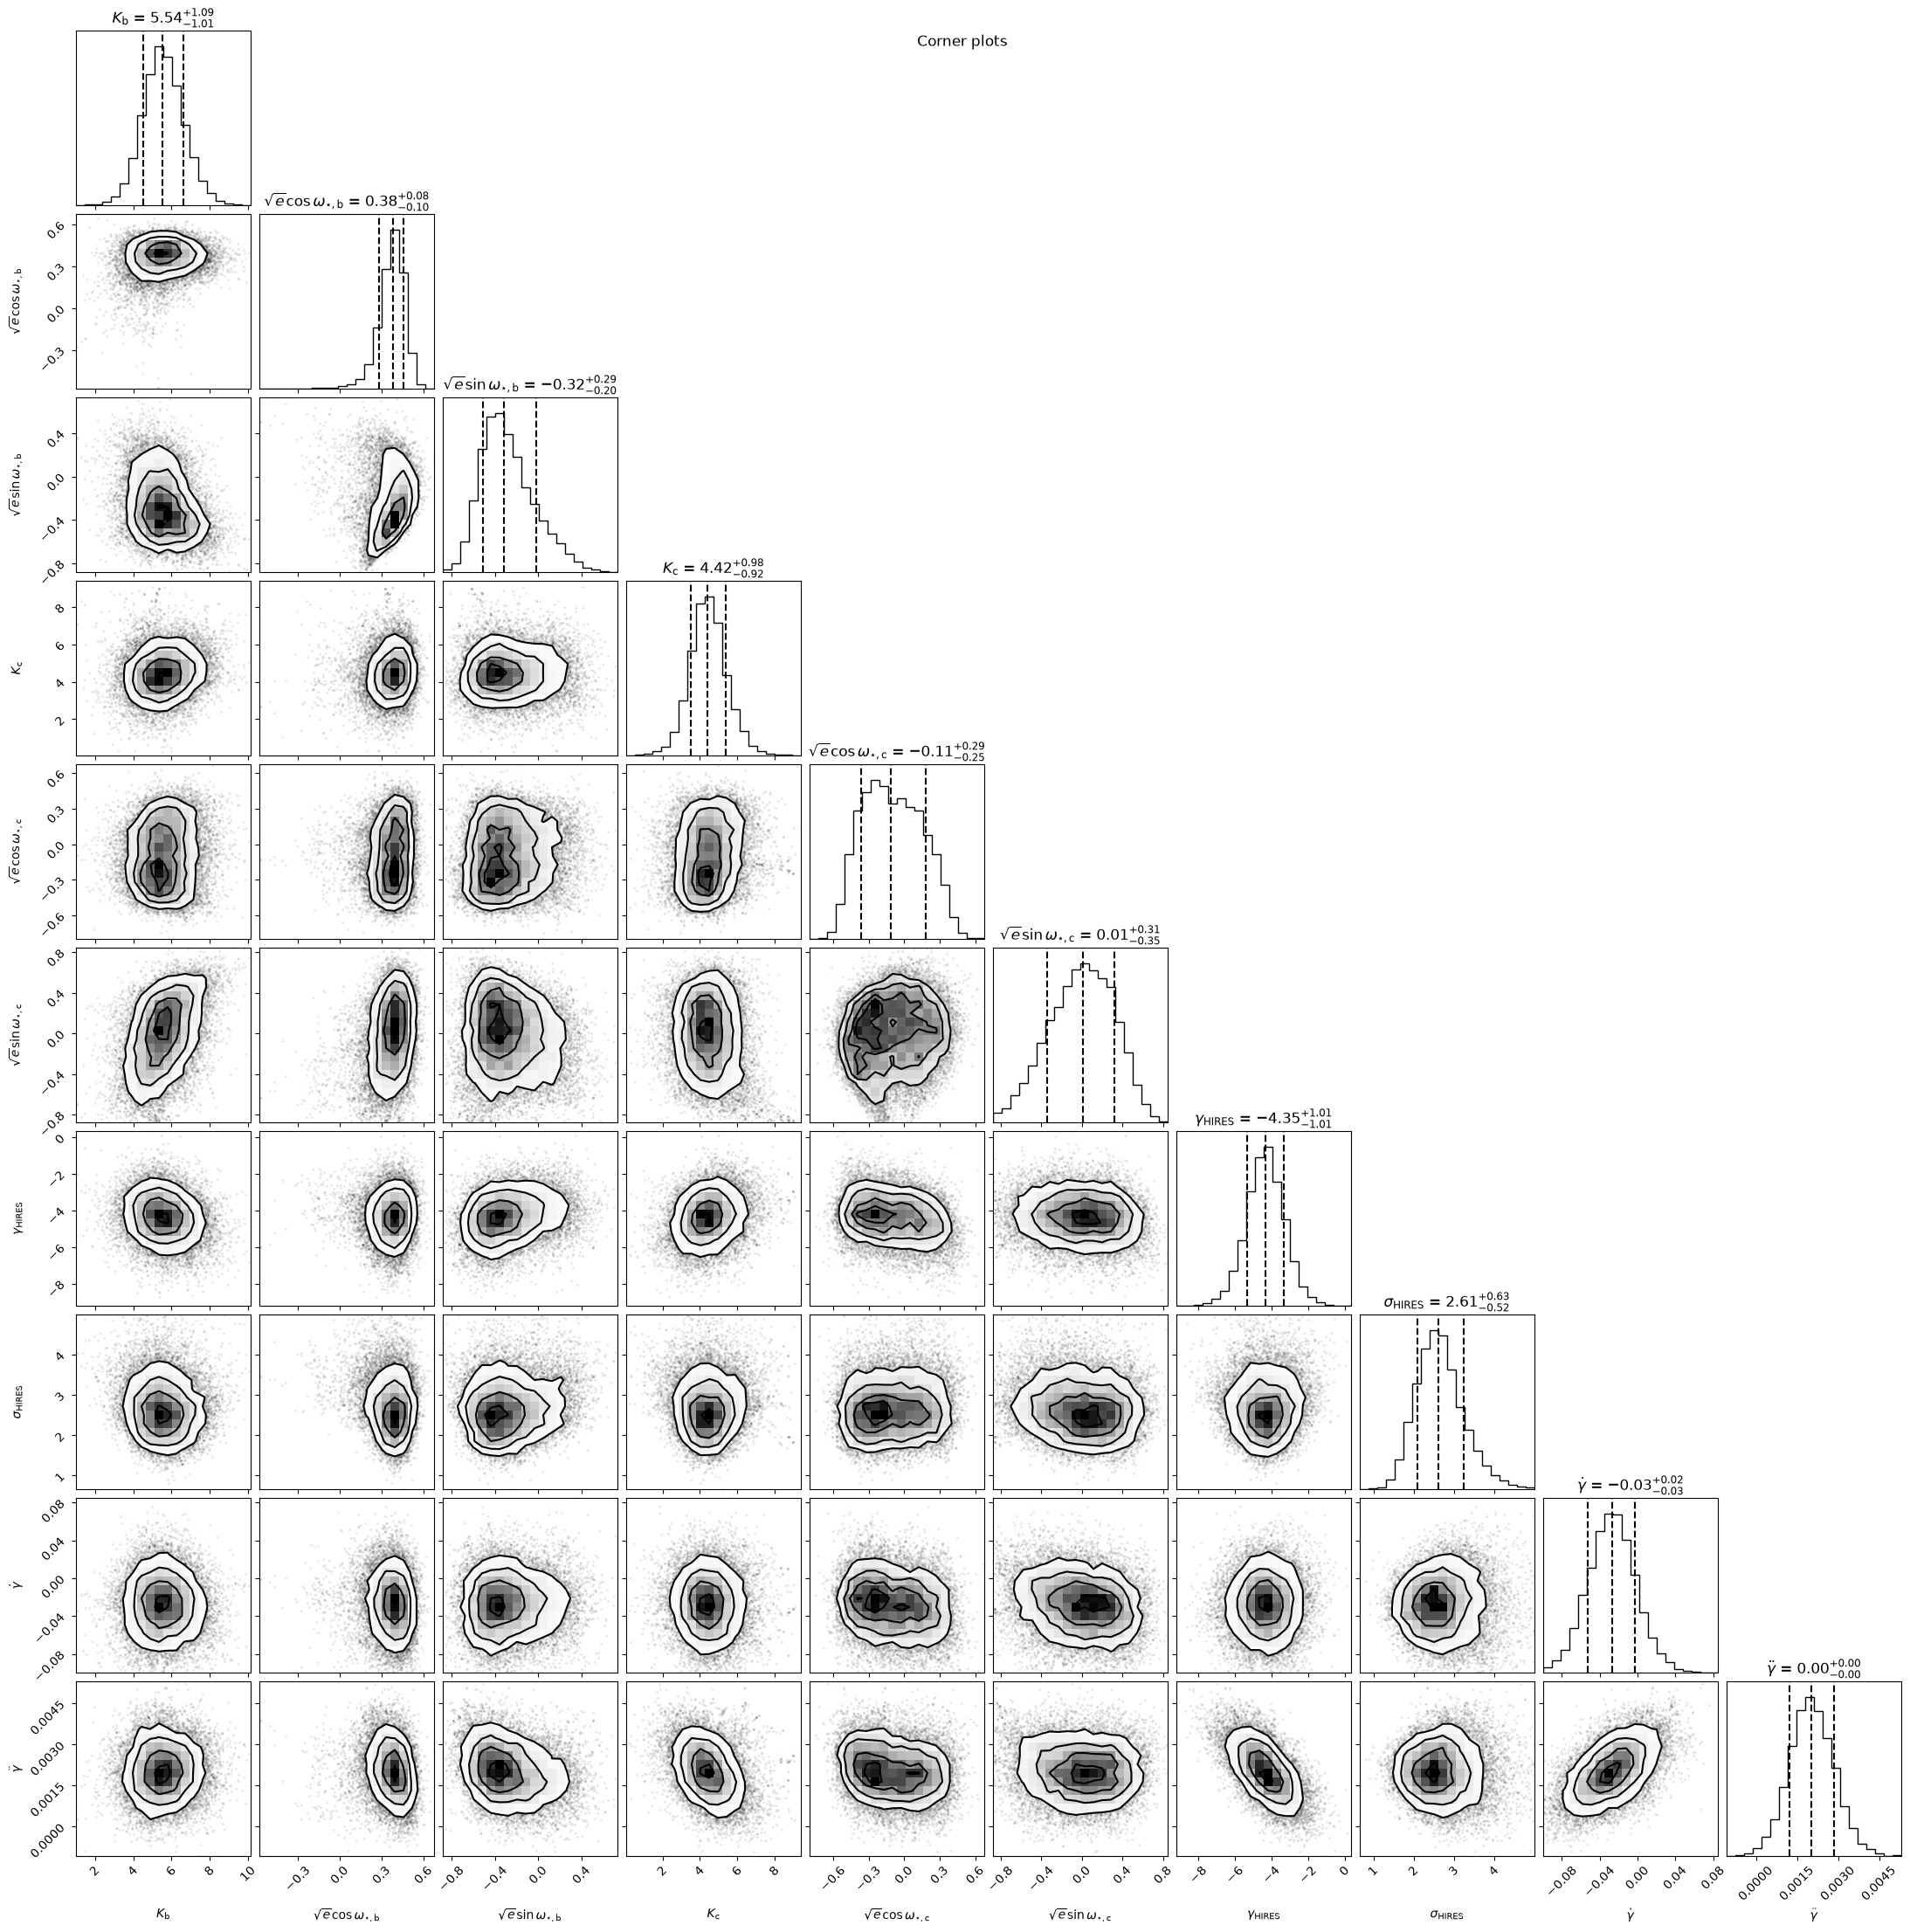

In [ ]:
fitter_se.plot_corner(discard_start=nburn, discard_end=0, thin=thin_rate, plot_datapoints=True, save=False)

#### Eccentricity posteriors

We can convert $\sqrt{e}\cos{\omega_\star}$ and $\sqrt{e}\sin{\omega_\star}$ chains back to $e$ (and $\omega_\star$) to inspect the posterior eccentricity directly.

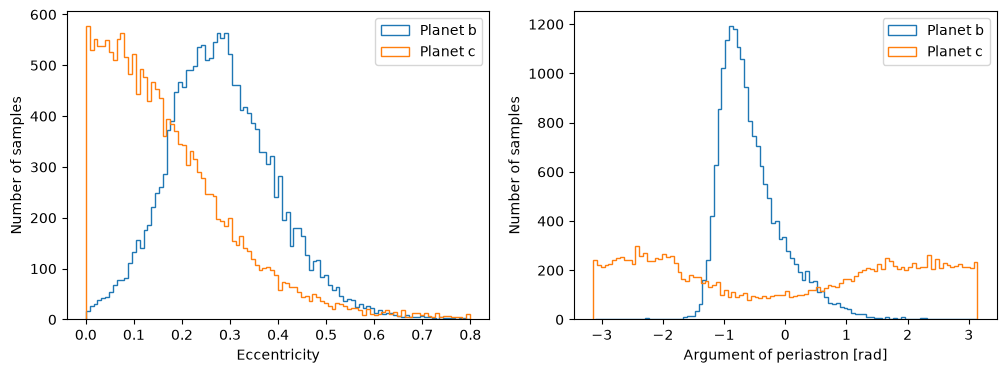

In [ ]:
eb_array, wb_array = parameterisation_se.convert_secosw_sesinw_to_e_w(samples_df_se["secosw_b"], samples_df_se["sesinw_b"])
ec_array, wc_array = parameterisation_se.convert_secosw_sesinw_to_e_w(samples_df_se["secosw_c"], samples_df_se["sesinw_c"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.hist(eb_array, bins=100, histtype="step", label="Planet b")
ax1.hist(ec_array, bins=100, histtype="step", label="Planet c")
ax1.set_xlabel("Eccentricity")
ax1.set_ylabel("Number of samples")
ax1.legend()

ax2.hist(wb_array, bins=100, histtype="step", label="Planet b")
ax2.hist(wc_array, bins=100, histtype="step", label="Planet c")
ax2.set_xlabel("Argument of periastron [rad]")
ax2.set_ylabel("Number of samples")
ax2.legend()

plt.show()

Planet b definitely looks eccentric, harder to tell for planet c though. (Remember that $\omega_\star$ becomes undefined when $e=0$, which might explain why $\omega_{\star,c}$ has such a wide spread: because a lot of the samples are where $e_c$ is close to 0, walkers making large moves in $\omega_{\star,c}$ will have little effect on the resultant RV, hence little change in resultant log-likelihood. So with both an uninformative prior and little change in the likelihood to constraint the parameter, the walker will just sweep through the entire parameter space for $\omega_{\star,c}$ aimlessly.)

#### Posterior RV and phase plots

Let's inspect how well our model matches the observed RV data. These functions evaluate the RV for every sample in the chains (after discarding and thinning), and plots the median and 68.3% interval of the RV at every timestep. (N.B. thinning can be useful here - these plots can take a while to generate as it has to calculate the RV curve for every sample in the chain.)

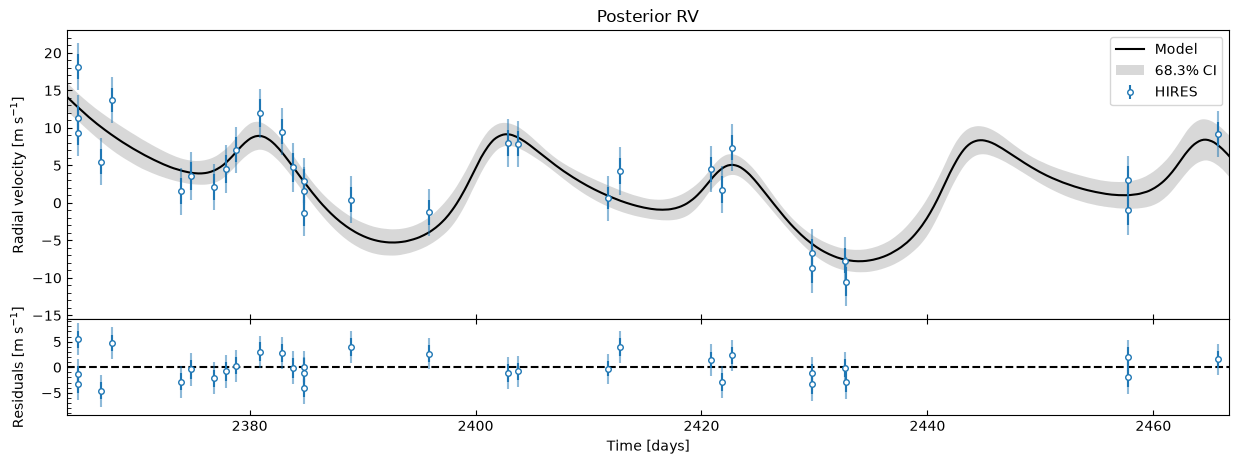

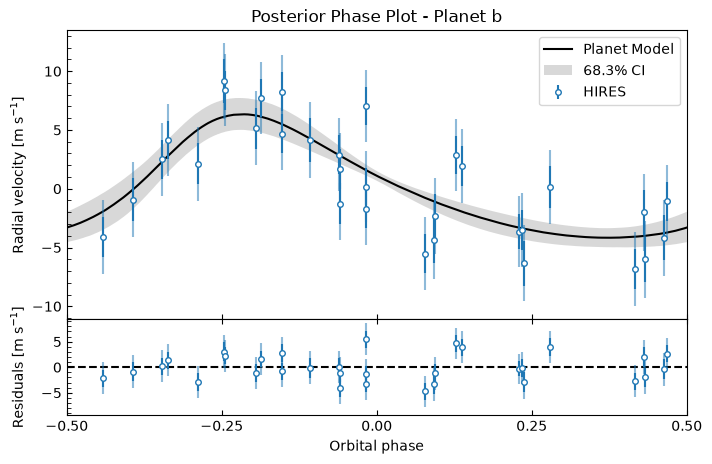

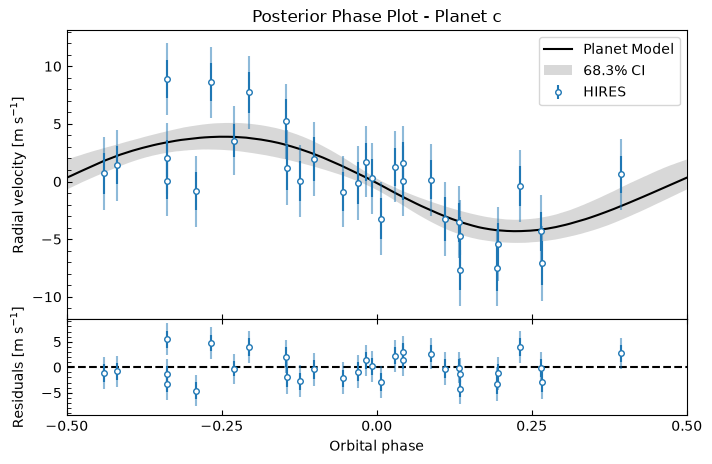

In [ ]:
fitter_se.plot_posterior_rv(discard_start=nburn, discard_end=0, thin=thin_rate)
fitter_se.plot_posterior_phase("b", discard_start=nburn, discard_end=0, thin=thin_rate)
fitter_se.plot_posterior_phase("c", discard_start=nburn, discard_end=0, thin=thin_rate)

### Minimum masses $M_p\sin{i}$

Let's see how allowing for eccentric orbits affects the mass estimates $M_p\sin{i}$. We will use the same stellar mass values from Petigura et al. 2016 that we used earlier.

In [ ]:
# Create a distribution of stellar mass values using the same published value and uncertainty as before
mstar = np.random.normal(loc=mstar_val, scale=mstar_err, size=len(samples_df_se))
# Ensure all values in mstar are positive (incredibly unlikely to be an issue with these values, but just in case)
while any(mstar <= 0):
    print(mstar[mstar <= 0])
    mstar[mstar <= 0] = np.random.normal(loc=mstar_val, scale=mstar_err, size=sum(mstar <= 0))

K2-24 b Mpsini: 24.52 +4.59 -4.40 M_earth
K2-24 c Mpsini: 25.37 +5.65 -5.32 M_earth


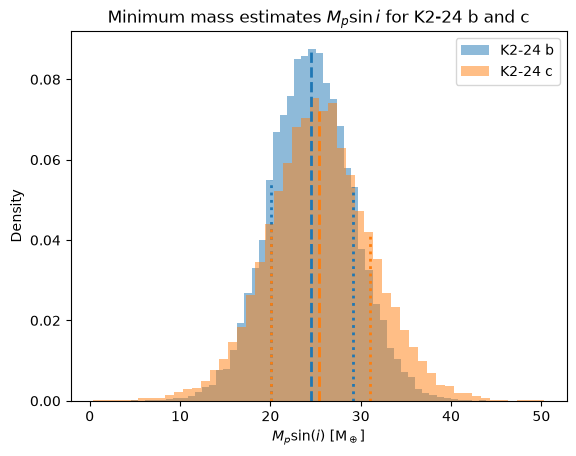

In [ ]:
# get the posterior samples (both free and fixed) as a dictionary
posterior_params_se = fitter_se.get_mcmc_posterior_dict(discard_start=nburn, discard_end=0, thin=thin_rate)  # get the fixed value for fixed parameters, get the MCMC samples for the free parameters

# we need to convert secosw and sesinw to e and w
# let's do this using the parameterisation class, parameterisation_se
posterior_params_se["e_b"], posterior_params_se["w_b"] = parameterisation_se.convert_secosw_sesinw_to_e_w(posterior_params_se["secosw_b"], posterior_params_se["sesinw_b"])
# and the same for _c
posterior_params_se["e_c"], posterior_params_se["w_c"] = parameterisation_se.convert_secosw_sesinw_to_e_w(posterior_params_se["secosw_c"], posterior_params_se["sesinw_c"])

# use the MCMC samples and the stellar mass distribution to get a distribution for Mp sin(i)
mpsini_b_se = calculate_mpsini(mstar, posterior_params_se["P_b"], posterior_params_se["K_b"], posterior_params_se["e_b"], unit="M_earth")
mpsini_c_se = calculate_mpsini(mstar, posterior_params_se["P_c"], posterior_params_se["K_c"], posterior_params_se["e_c"], unit="M_earth")

# Plot the mpsini posterior distributions overlapping
fig, ax = plt.subplots(1, 1)
ax.set_title("Minimum mass estimates $M_p\\sin{i}$ for K2-24 b and c")
ax.set_xlabel("$M_p \\sin(i)$ [M$_\\oplus$]")
ax.set_ylabel("Density")

# Plot both histograms first, normalised so they're visually comparable
plot_b_se = ax.hist(mpsini_b_se, bins=50, color="tab:blue", alpha=0.5, label="K2-24 b", density=True)
plot_c_se = ax.hist(mpsini_c_se, bins=50, color="tab:orange", alpha=0.5, label="K2-24 c", density=True)

# Get the final y-axis bound after both histograms are drawn
_, ymax_se = ax.get_ybound()

# Overplot percentile lines for planet b
ps_b_se = np.percentile(mpsini_b_se, [16, 50, 84])
heights_b = plot_b_se[0][np.searchsorted(plot_b_se[1], ps_b_se, side='left') - 1]
ax.axvline(ps_b_se[0], color='tab:blue', linestyle=':', linewidth=2, ymax=heights_b[0] / ymax_se)
ax.axvline(ps_b_se[1], color='tab:blue', linestyle='--', linewidth=2, ymax=heights_b[1] / ymax_se)
ax.axvline(ps_b_se[2], color='tab:blue', linestyle=':', linewidth=2, ymax=heights_b[2] / ymax_se)

# Overplot percentile lines for planet c
ps_c_se = np.percentile(mpsini_c_se, [16, 50, 84])
heights_c = plot_c_se[0][np.searchsorted(plot_c_se[1], ps_c_se, side='left') - 1]
ax.axvline(ps_c_se[0], color='tab:orange', linestyle=':', linewidth=2, ymax=heights_c[0] / ymax_se)
ax.axvline(ps_c_se[1], color='tab:orange', linestyle='--', linewidth=2, ymax=heights_c[1] / ymax_se)
ax.axvline(ps_c_se[2], color='tab:orange', linestyle=':', linewidth=2, ymax=heights_c[2] / ymax_se)

ax.legend(loc="upper right")

print(f"K2-24 b Mpsini: {ps_b_se[1]:.2f} +{ps_b_se[2]-ps_b_se[1]:.2f} -{ps_b_se[1]-ps_b_se[0]:.2f} M_earth")
print(f"K2-24 c Mpsini: {ps_c_se[1]:.2f} +{ps_c_se[2]-ps_c_se[1]:.2f} -{ps_c_se[1]-ps_c_se[0]:.2f} M_earth")

---

## Model comparison

### Minimum masses

Let's compare the mass estimates for the two planets in both the circular and eccentric models.

In [ ]:
print(f"K2-24 b Mpsini (circular) : {ps_b[1]:.2f} +{ps_b[2]-ps_b[1]:.2f} -{ps_b[1]-ps_b[0]:.2f} M_earth")
print(f"K2-24 b Mpsini (eccentric): {ps_b_se[1]:.2f} +{ps_b_se[2]-ps_b_se[1]:.2f} -{ps_b_se[1]-ps_b_se[0]:.2f} M_earth")
print(f"K2-24 c Mpsini (circular) : {ps_c[1]:.2f} +{ps_c[2]-ps_c[1]:.2f} -{ps_c[1]-ps_c[0]:.2f} M_earth")
print(f"K2-24 c Mpsini (eccentric): {ps_c_se[1]:.2f} +{ps_c_se[2]-ps_c_se[1]:.2f} -{ps_c_se[1]-ps_c_se[0]:.2f} M_earth")

K2-24 b Mpsini (circular) : 21.98 +4.43 -4.42 M_earth
K2-24 b Mpsini (eccentric): 24.52 +4.59 -4.40 M_earth
K2-24 c Mpsini (circular) : 23.53 +6.10 -6.26 M_earth
K2-24 c Mpsini (eccentric): 25.37 +5.65 -5.32 M_earth


### Goodness of fit and information criteria

Now let's compare the circular and eccentric models quantitatively using statistical metrics.

In [ ]:
# Calculate metrics for circular model
fitter_samples = fitter.get_samples_np(discard_start=nburn, discard_end=0, thin=thin_rate, flat=True)
fitter_medians = np.percentile(fitter_samples, 50, axis=0)
fitter_complete_dict = fitter.build_params_dict(fitter_medians)

fitter_chi2 = fitter.calculate_chi2(fitter_complete_dict)
fitter_loglike = fitter.calculate_log_likelihood(fitter_complete_dict)
fitter_aicc = fitter.calculate_aicc(fitter_complete_dict)
fitter_bic = fitter.calculate_bic(fitter_complete_dict)

print("Circular model metrics at 50th percentile:")
print(f"  Chi2:          {fitter_chi2:.2f}")
print(f"  Log-likelihood: {fitter_loglike:.2f}")
print(f"  AICc:           {fitter_aicc:.2f}")
print(f"  BIC:            {fitter_bic:.2f}")

Circular model metrics at 50th percentile:
  Chi2:          25.53
  Log-likelihood: -83.14
  AICc:           181.65
  BIC:            187.08


In [ ]:
# Calculate metrics for eccentric model
fitter_se_samples = fitter_se.get_samples_np(discard_start=nburn, discard_end=0, thin=thin_rate, flat=True)
fitter_se_medians = np.percentile(fitter_se_samples, 50, axis=0)
fitter_se_complete_dict = fitter_se.build_params_dict(fitter_se_medians)

fitter_se_chi2 = fitter_se.calculate_chi2(fitter_se_complete_dict)
fitter_se_loglike = fitter_se.calculate_log_likelihood(fitter_se_complete_dict)
fitter_se_aicc = fitter_se.calculate_aicc(fitter_se_complete_dict)
fitter_se_bic = fitter_se.calculate_bic(fitter_se_complete_dict)

print("Eccentric model metrics at 50th percentile:")
print(f"  Chi2:          {fitter_se_chi2:.2f}")
print(f"  Log-likelihood: {fitter_se_loglike:.2f}")
print(f"  AICc:           {fitter_se_aicc:.2f}")
print(f"  BIC:            {fitter_se_bic:.2f}")

Eccentric model metrics at 50th percentile:
  Chi2:          22.90
  Log-likelihood: -77.42
  AICc:           185.32
  BIC:            189.50


In [ ]:
print(f"\n{'Metric':<20} {'Circular':>12} {'Eccentric':>12}   {'':>20}")
print("-" * 70)
print(f"{'Free parameters':<20} {fitter.ndim:>12} {fitter_se.ndim:>12}")
print(f"{'Chi2':<20} {fitter_chi2:>12.2f} {fitter_se_chi2:>12.2f}   {'(lower is better)':>20}")
print(f"{'Log-likelihood':<20} {fitter_loglike:>12.2f} {fitter_se_loglike:>12.2f}   {'(higher is better)':>20}")
print(f"{'AICc':<20} {fitter_aicc:>12.2f} {fitter_se_aicc:>12.2f}   {'(lower is better)':>20}")
print(f"{'BIC':<20} {fitter_bic:>12.2f} {fitter_se_bic:>12.2f}   {'(lower is better)':>20}")


Metric                   Circular    Eccentric                       
----------------------------------------------------------------------
Free parameters                 6           10
Chi2                        25.53        22.90      (lower is better)
Log-likelihood             -83.14       -77.42     (higher is better)
AICc                       181.65       185.32      (lower is better)
BIC                        187.08       189.50      (lower is better)


The eccentric model fits the data better numerically (lower $\chi^2$ and higher $\ln{\mathcal{L}}$), but both AICc and BIC prefer the circular model once they penalise its 4 additional free eccentricity parameters (to prevent overfitting). Looking at the earlier results, there isn't much evidence that planet c is eccentric, so the contribution to the RV (and therefore likelihood) for that planet will be nearly the same as in the circular model, hence similar $\chi^2$ and $\ln{\mathcal{L}}$, whereas the AICc and BIC are penalising the extra parameters.

So the goodness-of-fit metrics and the information criteria point in opposite directions. The principled way to settle this is the log Bayesian evidence $\ln\mathcal{Z}$, which Ravest supports via the Learned Harmonic Mean Estimator from the `harmonic` package, using the MCMC samples we already have. See [Example 4: using the Learned Harmonic Mean Estimator](https://ravest.readthedocs.io/en/latest/Examples/example_4_harmonic.html) for details.

Perhaps an additional exercise for the reader is seeing what happens if you fix planet c to be circular, but allow planet b to be eccentric...